In [21]:
import cv2
import ale_py
import gymnasium as gym
import torch

from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecFrameStack
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.atari_wrappers import FireResetEnv

In [2]:
import os
import time
import glob
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
gym.register_envs(ale_py)

In [4]:
class WhitePatchBreakout(gym.Wrapper):
    def __init__(self, env, apply_patch=False, region=(20, 40, 30, 30)):
        super().__init__(env)
        self.apply_patch = apply_patch
        self.x, self.y, self.w, self.h = region

    def _paint_patch(self, img):
        if not self.apply_patch:
            return img
        
        # Copia para não alterar o buffer original inadvertidamente
        img = img.copy()
        
        # Detecta dimensões (pode ser 84x84 ou a resolução nativa no render)
        H, W = img.shape[:2]
        
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante que o desenho não exceda as bordas
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            # Pinta de branco (255). Funciona tanto para RGB quanto Grayscale se ajustado
            img[y:y_end, x:x_end] = 255
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._paint_patch(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._paint_patch(obs), reward, terminated, truncated, info

    def render(self):
        # Mágica para o vídeo: Pega o render original e aplica a mancha nele
        img = self.env.render()
        return self._paint_patch(img)

In [5]:
class BlurBreakout(gym.Wrapper):
    def __init__(self, env, apply_blur=False, region=(20, 40, 30, 30), ksize=21):
        super().__init__(env)
        self.apply_blur = apply_blur
        self.x, self.y, self.w, self.h = region
        self.ksize = ksize if ksize % 2 == 1 else ksize + 1

    def _apply_blur(self, img):
        if not self.apply_blur:
            return img
        
        img = img.copy()
        H, W = img.shape[:2]
        x, y, w, h = self.x, self.y, self.w, self.h
        
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            roi = img[y:y_end, x:x_end]
            # Aplica Gaussian Blur na região de interesse
            blurred_roi = cv2.GaussianBlur(roi, (self.ksize, self.ksize), 0)
            img[y:y_end, x:x_end] = blurred_roi
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._apply_blur(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._apply_blur(obs), reward, terminated, truncated, info
    
    def render(self):
        img = self.env.render()
        return self._apply_blur(img)

In [6]:
class GrayscaleWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Força explicitamente o shape (H, W, 1) para compatibilidade com SB3
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(old_shape[0], old_shape[1], 1), dtype=np.uint8
        )

    def _convert(self, obs):
        # Se for RGB (3 canais), converte para Gray e mantém dimensão extra
        if obs.ndim == 3 and obs.shape[2] == 3:
            return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)[:, :, None]
        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._convert(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._convert(obs), reward, terminated, truncated, info

In [7]:
def make_training_env(with_blur=False, change='white_patch', zone='middle', log_dir="./logs/"):
    """
    Cria ambiente com zonas configuráveis.
    Zonas disponíveis: 'top', 'middle', 'bottom'.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # --- CORREÇÃO DE ESCALA ---
    # A imagem da IA tem apenas 84x84 pixels.
    # Tamanho da Mancha: 40x40 pixels.
    # Centralização X: (84 - 40) / 2 = 22.
    
    presets = {
        # ZONA 1: TOP (TIJOLOS)
        # Y=25: Centraliza a mancha na massa de tijolos coloridos.
        'top':    (32, 25, 20, 20), 

        # ZONA 2: MIDDLE (TRAJETÓRIA)
        # Y=50: Fica no espaço vazio logo acima da linha de perigo.
        'middle': (32, 50, 20, 20), 

        # ZONA 3: BOTTOM (PADDLE)
        # Y=64: Vai exatamente até o pixel 84 (64+20=84).
        # Cobre apenas o centro do paddle, exigindo precisão.
        'bottom': (32, 64, 20, 20)  
    }
    
    region = presets.get(zone, (22, 38, 40, 40))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        
        # 1. Redimensiona PRIMEIRO (O mundo vira 84x84 aqui)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 2. Aplica a Mancha DEPOIS (Usando as coordenadas convertidas acima)
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = GrayscaleWrapper(env)
        
        if log_dir:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(log_dir, f"monitor_{zone}_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [8]:
BASE_FOLDER = "treino_dqn"

In [9]:
def get_latest_log_file(folder):
    if not os.path.exists(folder): return None
    search_path = os.path.join(folder, "monitor*.csv")
    files = glob.glob(search_path)
    if not files: return None
    return max(files, key=os.path.getmtime)

def plot_advanced_analysis(log_dir_1, name_1, log_dir_2, name_2):
    
    # Configura estilo visual (se disponível, senão usa padrão)
    try:
        plt.style.use('seaborn-v0_8-darkgrid')
    except:
        plt.style.use('ggplot')

    def read_dataframe(folder):
        file_path = get_latest_log_file(folder)
        if file_path is None:
            print(f"Log não encontrado em: {folder}")
            return None
        try:
            # skiprows=1 é padrão do SB3 (Monitor wrapper)
            df = pd.read_csv(file_path, skiprows=1)
            # Verifica se tem as colunas necessárias
            if not {'r', 'l', 't'}.issubset(df.columns):
                return None
            return df
        except Exception as e:
            print(f"Erro ao ler {file_path}: {e}")
            return None

    df1 = read_dataframe(log_dir_1)
    df2 = read_dataframe(log_dir_2)

    if df1 is None and df2 is None:
        print("Nenhum dado válido para plotar.")
        return

    # Layout: Grid 2x2 (Topo expandido)
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1]) # Topo um pouco maior

    # --- Cores e Estilos ---
    color1, color2 = '#1f77b4', '#d62728' # Azul e Vermelho profissionais
    alpha_fill = 0.2

    # --- GRÁFICO 1: RECOMPENSA (Curva Principal) ---
    ax1 = fig.add_subplot(gs[0, :])
    
    # Função para plotar com suavização inteligente
    def plot_smooth(ax, df, label, color, linestyle='-'):
        if df is None or df.empty: return
        
        # Eixo X: Total Timesteps
        x = df['l'].cumsum()
        y = df['r']
        
        # Janela dinâmica: 5% do total de episódios ou mínimo de 10
        # Isso evita gráficos "em branco" se o treino for curto
        window = max(10, len(df) // 20)
        
        y_smooth = y.rolling(window=window, min_periods=1).mean()
        std_smooth = y.rolling(window=window, min_periods=1).std()
        
        ax.plot(x, y_smooth, label=f"{label} (Média Móvel {window})", color=color, linewidth=2, linestyle=linestyle)
        ax.fill_between(x, y_smooth - std_smooth, y_smooth + std_smooth, color=color, alpha=alpha_fill)

    plot_smooth(ax1, df1, name_1, color1)
    plot_smooth(ax1, df2, name_2, color2, linestyle='--')

    ax1.set_title("1. Curva de Aprendizado (Pontuação)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Recompensa Média", fontsize=12)
    ax1.set_xlabel("Steps (Passos de Treino)", fontsize=12)
    ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    ax1.margins(x=0)

    # --- GRÁFICO 2: SOBREVIVÊNCIA (Duração) ---
    ax2 = fig.add_subplot(gs[1, 0])
    
    def plot_len(ax, df, color, linestyle='-'):
        if df is None or df.empty: return
        x = df['l'].cumsum()
        window = max(10, len(df) // 20)
        y_len = df['l'].rolling(window=window, min_periods=1).mean()
        ax.plot(x, y_len, color=color, linewidth=2, linestyle=linestyle)

    plot_len(ax2, df1, color1)
    plot_len(ax2, df2, color2, linestyle='--')
    
    ax2.set_title("2. Sobrevivência (Duração do Episódio)", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Frames por Jogo")
    ax2.set_xlabel("Steps")

    # --- GRÁFICO 3: FPS (Velocidade) ---
    ax3 = fig.add_subplot(gs[1, 1])
    
    fps_names = []
    fps_values = []
    colors = []

    if df1 is not None and not df1.empty:
        # FPS Médio Total = Total Steps / Total Time
        fps1 = df1['l'].cumsum().iloc[-1] / df1['t'].iloc[-1]
        fps_names.append(name_1)
        fps_values.append(fps1)
        colors.append(color1)

    if df2 is not None and not df2.empty:
        fps2 = df2['l'].cumsum().iloc[-1] / df2['t'].iloc[-1]
        fps_names.append(name_2)
        fps_values.append(fps2)
        colors.append(color2)

    if fps_values:
        bars = ax3.bar(fps_names, fps_values, color=colors, alpha=0.8, width=0.5)
        ax3.set_title("3. Velocidade de Processamento", fontsize=12, fontweight='bold')
        ax3.set_ylabel("FPS (Frames/segundo)")
        
        # Adiciona o número em cima da barra
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        # Ajusta limite Y para dar espaço ao texto
        ax3.set_ylim(0, max(fps_values) * 1.2)

    plt.tight_layout()
    plt.show()

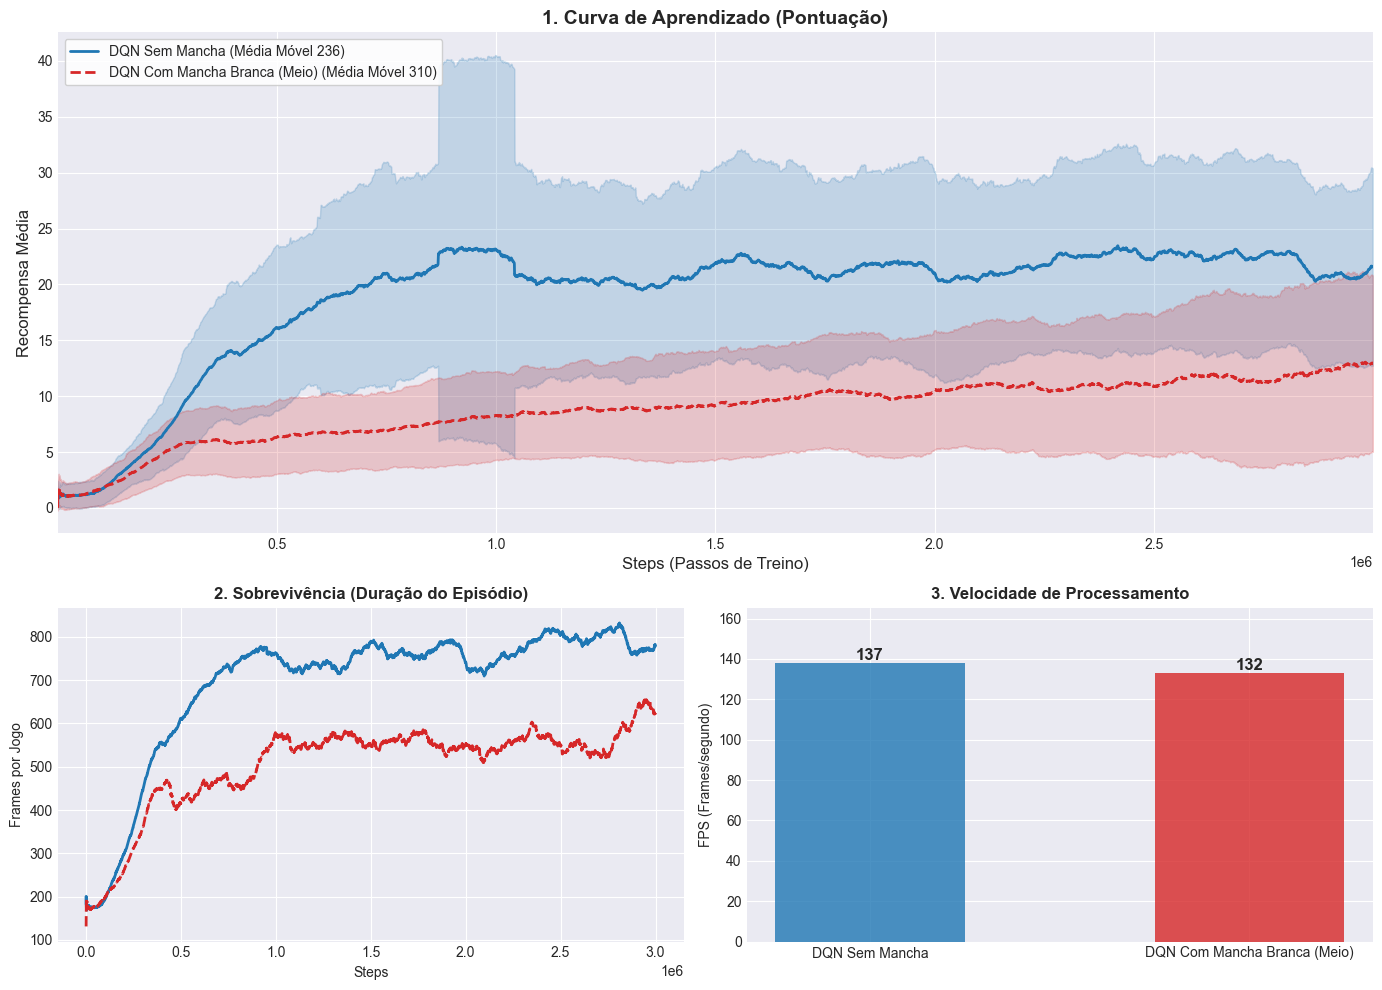

In [10]:
plot_advanced_analysis(
    log_dir_1=f"{BASE_FOLDER}/logs_normal",
    name_1="DQN Sem Mancha",
    log_dir_2=f"{BASE_FOLDER}/logs_hipotese_middle",
    name_2="DQN Com Mancha Branca (Meio)"
)

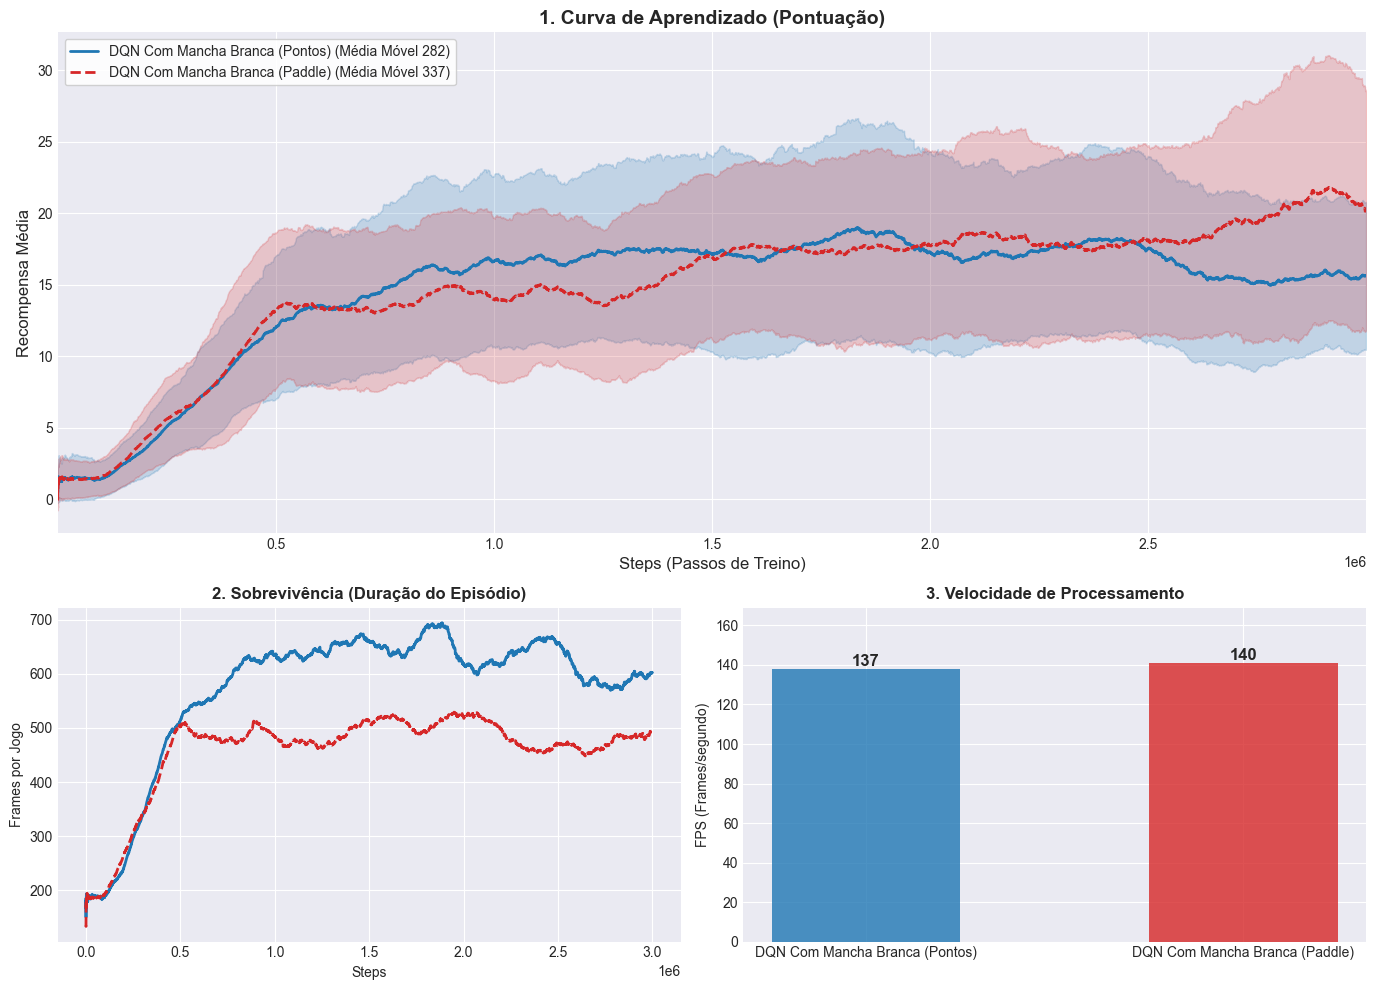

In [11]:
plot_advanced_analysis(
    log_dir_1=f"{BASE_FOLDER}/logs_hipotese_top",
    name_1="DQN Com Mancha Branca (Pontos)",
    log_dir_2=f"{BASE_FOLDER}/logs_hipotese_bottom",
    name_2="DQN Com Mancha Branca (Paddle)"
)

In [12]:
def plot_multiline_analysis(experiments_dict, title_suffix=""):
    """
    Plota múltiplos agentes no mesmo gráfico.
    experiments_dict: Dicionário { "Nome da Legenda": "Caminho/Da/Pasta" }
    """
    
    # Configuração de Estilo
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 10})

    # Cores distintas para os 4 agentes (Azul, Laranja, Verde, Vermelho)
    palette = sns.color_palette("tab10", n_colors=len(experiments_dict))
    
    # Prepara os dados
    data_storage = {}
    
    for label, folder in experiments_dict.items():
        file_path = get_latest_log_file(folder)
        if file_path:
            try:
                df = pd.read_csv(file_path, skiprows=1)
                # Verifica integridade
                if {'r', 'l', 't'}.issubset(df.columns):
                    data_storage[label] = df
                else:
                    print(f"Dados corrompidos em: {label}")
            except:
                print(f"Erro ao ler: {label}")
        else:
            print(f"Log não encontrado para: {label} ({folder})")

    if not data_storage:
        print("Nenhum dado válido para plotar.")
        return

    # --- PLOTAGEM ---
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1])

    # 1. GRÁFICO DE RECOMPENSA (PRINCIPAL)
    ax1 = fig.add_subplot(gs[0, :])
    
    for i, (name, df) in enumerate(data_storage.items()):
        color = palette[i]
        x = df['l'].cumsum()
        y = df['r']
        
        # Janela de suavização dinâmica (mínimo 50, ou 1% dos dados)
        window = max(50, len(df) // 100)
        
        y_smooth = y.rolling(window=window, min_periods=1).mean()
        std_smooth = y.rolling(window=window, min_periods=1).std()
        
        ax1.plot(x, y_smooth, label=f"{name}", color=color, linewidth=2)
        # Sombra do desvio padrão (mais transparente para não poluir com 4 linhas)
        ax1.fill_between(x, y_smooth - std_smooth, y_smooth + std_smooth, color=color, alpha=0.1)

    ax1.set_title(f"1. Curva de Aprendizado: Recompensa Média {title_suffix}", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Score (Pontos)")
    ax1.set_xlabel("Steps (Passos Totais)")
    ax1.legend(loc='upper left', fontsize=11, frameon=True)
    ax1.margins(x=0)

    # 2. GRÁFICO DE SOBREVIVÊNCIA
    ax2 = fig.add_subplot(gs[1, 0])
    
    for i, (name, df) in enumerate(data_storage.items()):
        color = palette[i]
        x = df['l'].cumsum()
        window = max(50, len(df) // 100)
        y_len = df['l'].rolling(window=window, min_periods=1).mean()
        ax2.plot(x, y_len, color=color, label=name)

    ax2.set_title("2. Sobrevivência (Duração)", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Frames por Episódio")
    ax2.set_xlabel("Steps")
    # ax2.legend() # Opcional aqui para não poluir

    # 3. GRÁFICO DE VELOCIDADE (FPS)
    ax3 = fig.add_subplot(gs[1, 1])
    
    names = []
    fps_values = []
    bar_colors = []

    for i, (name, df) in enumerate(data_storage.items()):
        if not df.empty:
            total_steps = df['l'].cumsum().iloc[-1]
            total_time = df['t'].iloc[-1]
            fps = total_steps / total_time if total_time > 0 else 0
            
            names.append(name)
            fps_values.append(fps)
            bar_colors.append(palette[i])

    bars = ax3.bar(names, fps_values, color=bar_colors, alpha=0.8)
    ax3.set_title("3. Velocidade de Treinamento", fontsize=12, fontweight='bold')
    ax3.set_ylabel("FPS")
    ax3.set_xticklabels(names, rotation=15, ha='right')

    # Valor do FPS em cima da barra
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

In [13]:
experimentos_dqn = {
    "Normal (Limpo)": "./treino_dqn/logs_normal",
    "Zona Top":       "./treino_dqn/logs_hipotese_top",
    "Zona Middle":    "./treino_dqn/logs_hipotese_middle",
    "Zona Bottom":    "./treino_dqn/logs_hipotese_bottom"
}

C:\Users\user\AppData\Local\Temp\ipykernel_8476\3973725779.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(names, rotation=15, ha='right')


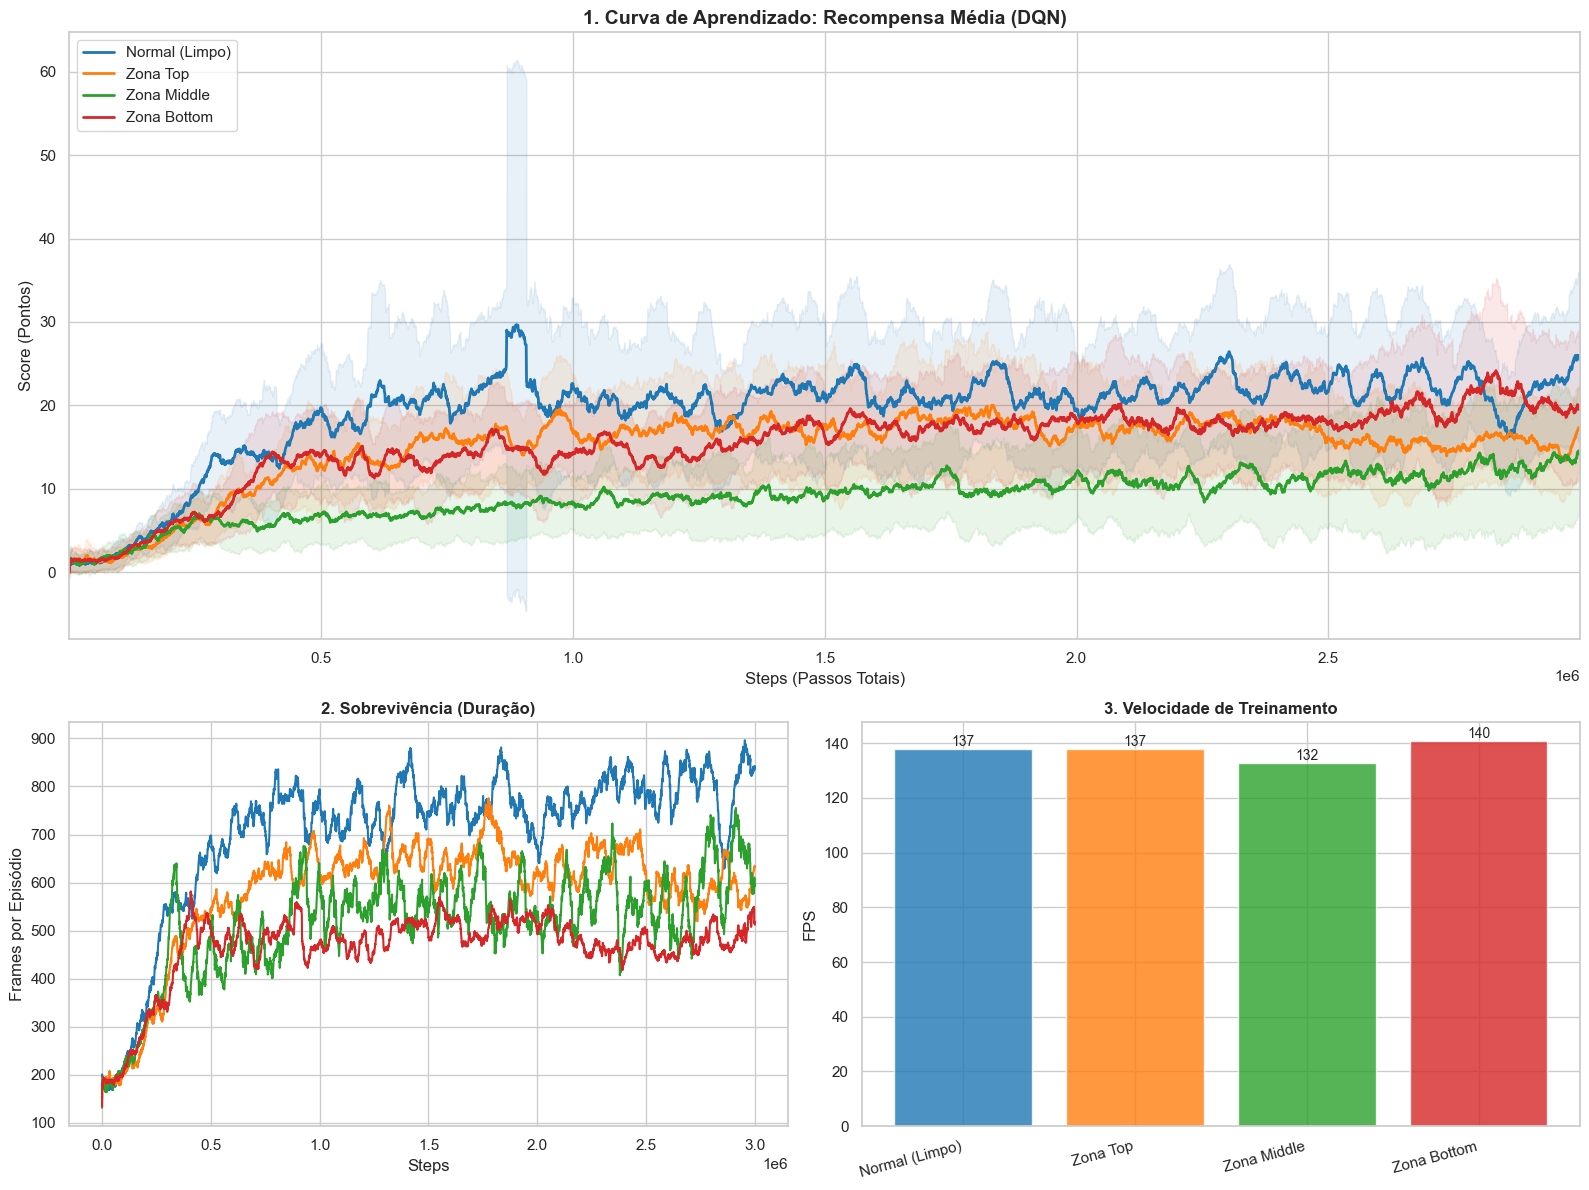

In [14]:
plot_multiline_analysis(experimentos_dqn, title_suffix="(DQN)")

In [ ]:
def run_cross_eval(algo_class, base_folder, n_episodes=20):
    algo_name = algo_class.__name__
    prefix = "dqn" if algo_name == "DQN" else "ppo"

    # 1. Definir Agentes e Ambientes
    agents = {
        "Normal": os.path.join(base_folder, f"{prefix}_breakout_normal"),
        "Top":    os.path.join(base_folder, f"{prefix}_breakout_zone_top"),
        # "Mid":    os.path.join(base_folder, f"{prefix}_breakout_zone_middle"),
        # "Bot":    os.path.join(base_folder, f"{prefix}_breakout_zone_bottom"),
    }
    envs_config = {
        "Amb. Normal": (False, 'middle'),
        "Amb. Top":    (True, 'top'),
        "Amb. Mid":    (True, 'middle'),
        "Amb. Bot":    (True, 'bottom')
    }

    results = []
    print(f"--- Iniciando Avaliação Cruzada ({algo_name}) ---")

    for ag_name, model_path in agents.items():
        if not os.path.exists(model_path + ".zip"): 
            print(f"Pulei {ag_name} (não achado)"); continue

        print(f"Avaliando Agente: {ag_name}...")
        model = algo_class.load(model_path)

        for env_name, (blur, zone) in envs_config.items():
            print(f"No ambiente: {env_name}...")
            env = make_training_env(with_blur=blur, zone=zone)

            rewards = []
            lengths = []

            obs = env.reset()
            for _ in range(n_episodes):
                if _ % 10:
                    print(f"{(_+1)/{n_episodes}*100}% episódios completados. \n")
                done = False
                ep_r = 0
                ep_l = 0
                while not done:
                    action, _ = model.predict(obs, deterministic=True)
                    obs, r, done, _ = env.step(action)
                    ep_r += r[0]
                    ep_l += 1
                rewards.append(ep_r)
                lengths.append(ep_l)
                obs = env.reset()

            # Calcula Métricas
            mean_r = np.mean(rewards)
            mean_l = np.mean(lengths)
            # Eficiência: Pontos ganhos por frame sobrevivido
            # (Evita divisão por zero somando 1e-6)
            efficiency = mean_r / (mean_l + 1e-6) * 100 

            results.append({
                "Agente": ag_name, "Ambiente": env_name, 
                "Score": mean_r, "Sobrevivência": mean_l, "Eficiência (x100)": efficiency
            })
            env.close()

    # --- PLOTAGEM DOS 3 HEATMAPS ---
    df = pd.DataFrame(results)
    metrics = ["Score", "Sobrevivência", "Eficiência (x100)"]

    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    for i, metric in enumerate(metrics):
        pivot = df.pivot(index="Agente", columns="Ambiente", values=metric)
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", ax=axes[i], linewidths=.5)
        axes[i].set_title(f"{metric} - {algo_name}")

    plt.tight_layout()
    plt.show()

    return df

--- Iniciando Avaliação Cruzada (DQN) ---
Avaliando Agente: Normal...
No ambiente: Amb. Normal...
  Episódio 1/100...  Episódio 2/100...  Episódio 3/100...  Episódio 4/100...  Episódio 5/100...  Episódio 6/100...  Episódio 7/100...  Episódio 8/100...  Episódio 9/100...  Episódio 10/100...  Episódio 11/100...  Episódio 12/100...  Episódio 13/100...  Episódio 14/100...  Episódio 15/100...  Episódio 16/100...  Episódio 17/100...  Episódio 18/100...  Episódio 19/100...  Episódio 20/100...  Episódio 21/100...  Episódio 22/100...  Episódio 23/100...  Episódio 24/100...  Episódio 25/100...  Episódio 26/100...  Episódio 27/100...  Episódio 28/100...  Episódio 29/100...  Episódio 30/100...  Episódio 31/100...  Episódio 32/100...  Episódio 33/100...  Episódio 34/100...  Episódio 35/100...  Episódio 36/100...  Episódio 37/100...  Episódio 38/100...  Episódio 39/100...  Episódio 40/100...  Episódio 41/100...  Episódio 42/100...  Episódio 43/100...  Episódio 44/100...  Episódio 45/100...  Episódio 

c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\stable_baselines3\common\buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 5.65GB > 5.29GB
  warnings.warn(


No ambiente: Amb. Normal...
  Episódio 1/100...  Episódio 2/100...  Episódio 3/100...  Episódio 4/100...  Episódio 5/100...  Episódio 6/100...  Episódio 7/100...  Episódio 8/100...  Episódio 9/100...  Episódio 10/100...  Episódio 11/100...  Episódio 12/100...  Episódio 13/100...  Episódio 14/100...  Episódio 15/100...  Episódio 16/100...  Episódio 17/100...  Episódio 18/100...  Episódio 19/100...  Episódio 20/100...  Episódio 21/100...  Episódio 22/100...  Episódio 23/100...  Episódio 24/100...  Episódio 25/100...  Episódio 26/100...  Episódio 27/100...  Episódio 28/100...  Episódio 29/100...  Episódio 30/100...  Episódio 31/100...  Episódio 32/100...  Episódio 33/100...  Episódio 34/100...  Episódio 35/100...  Episódio 36/100...  Episódio 37/100...  Episódio 38/100...  Episódio 39/100...  Episódio 40/100...  Episódio 41/100...  Episódio 42/100...  Episódio 43/100...  Episódio 44/100...  Episódio 45/100...  Episódio 46/100...  Episódio 47/100...  Episódio 48/100...  Episódio 49/100... 

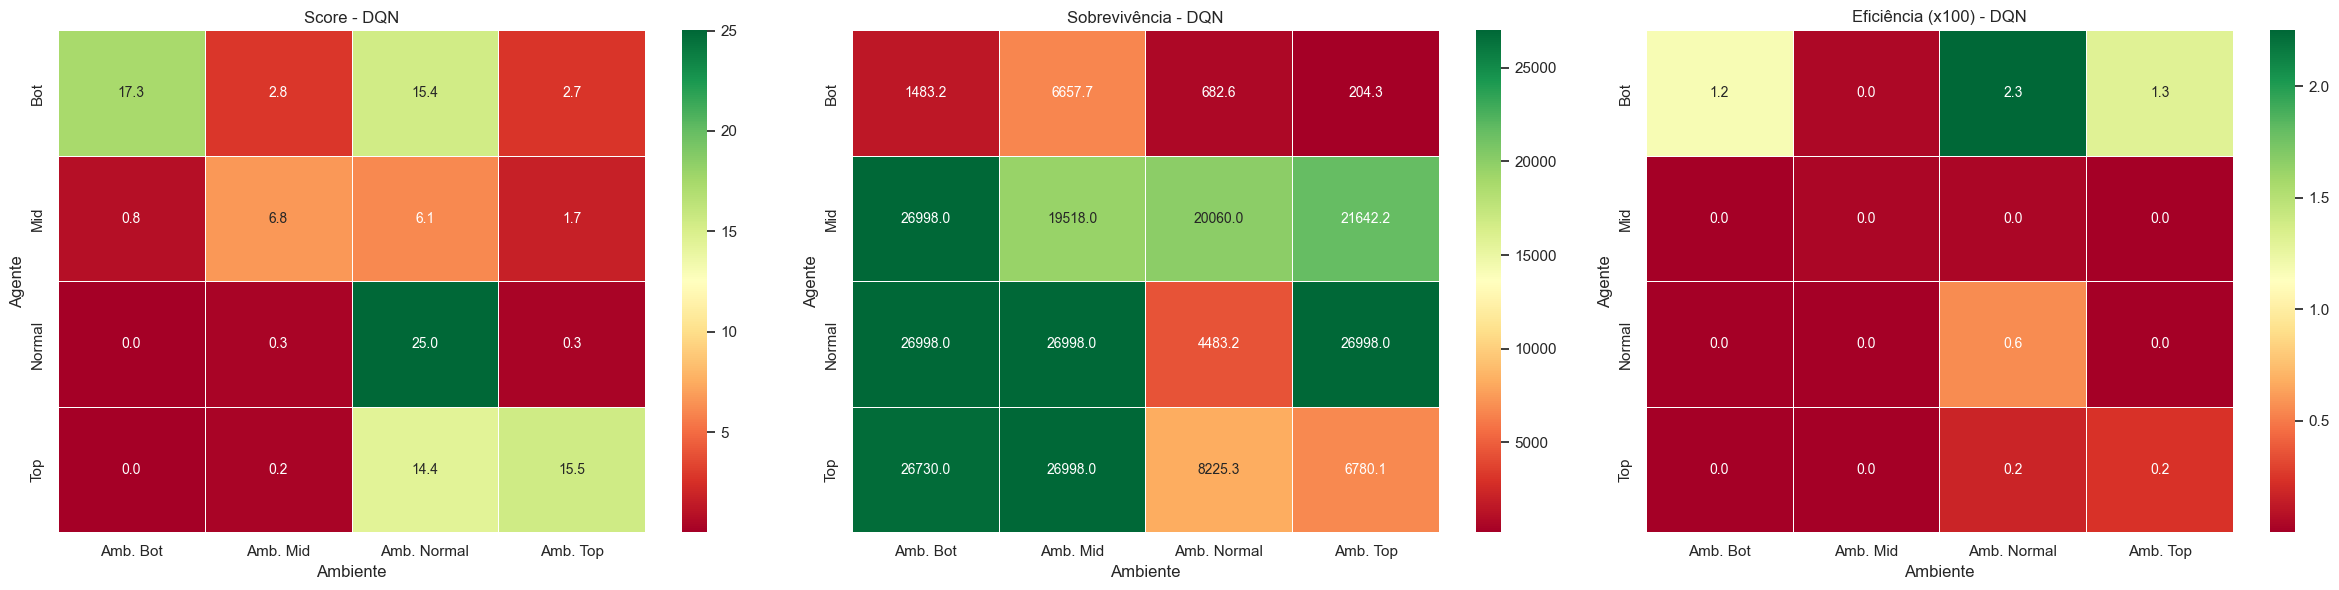

In [ ]:
df = run_cross_eval(DQN, "treino_dqn", n_episodes=100)

In [20]:
df.to_csv("cross_eval_dqn.csv", index=False)

In [ ]:
df

,Agente,Ambiente,Score,Sobrevivência,Eficiência (x100)
0,Normal,Amb. Normal,17.0,26998.0,0.062968
1,Normal,Amb. Top,0.0,26998.0,0.000000
2,Normal,Amb. Mid,2.0,26998.0,0.007408
3,Normal,Amb. Bot,0.0,26998.0,0.000000
4,Top,Amb. Normal,6.0,26998.0,0.022224
5,Top,Amb. Top,20.0,546.0,3.663004
6,Top,Amb. Mid,0.0,26998.0,0.000000
7,Top,Amb. Bot,0.0,26998.0,0.000000
8,Mid,Amb. Normal,8.0,26998.0,0.029632
9,Mid,Amb. Top,2.0,26998.0,0.007408


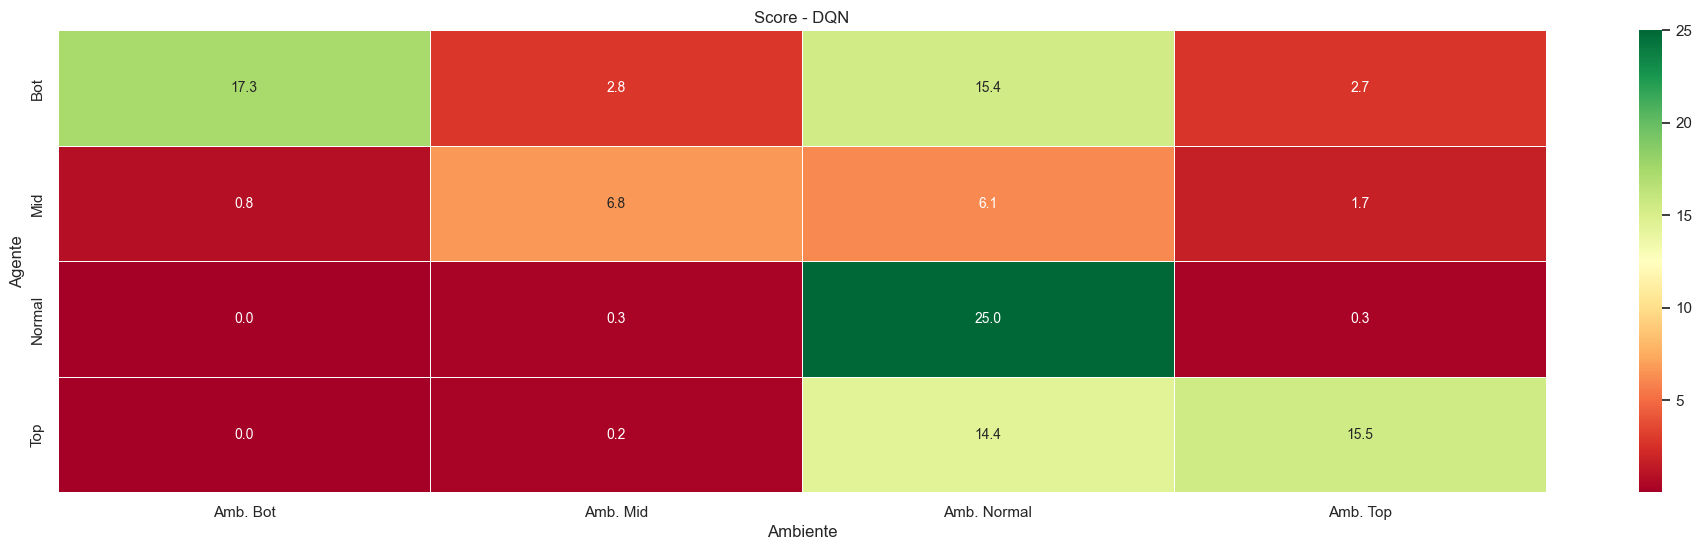

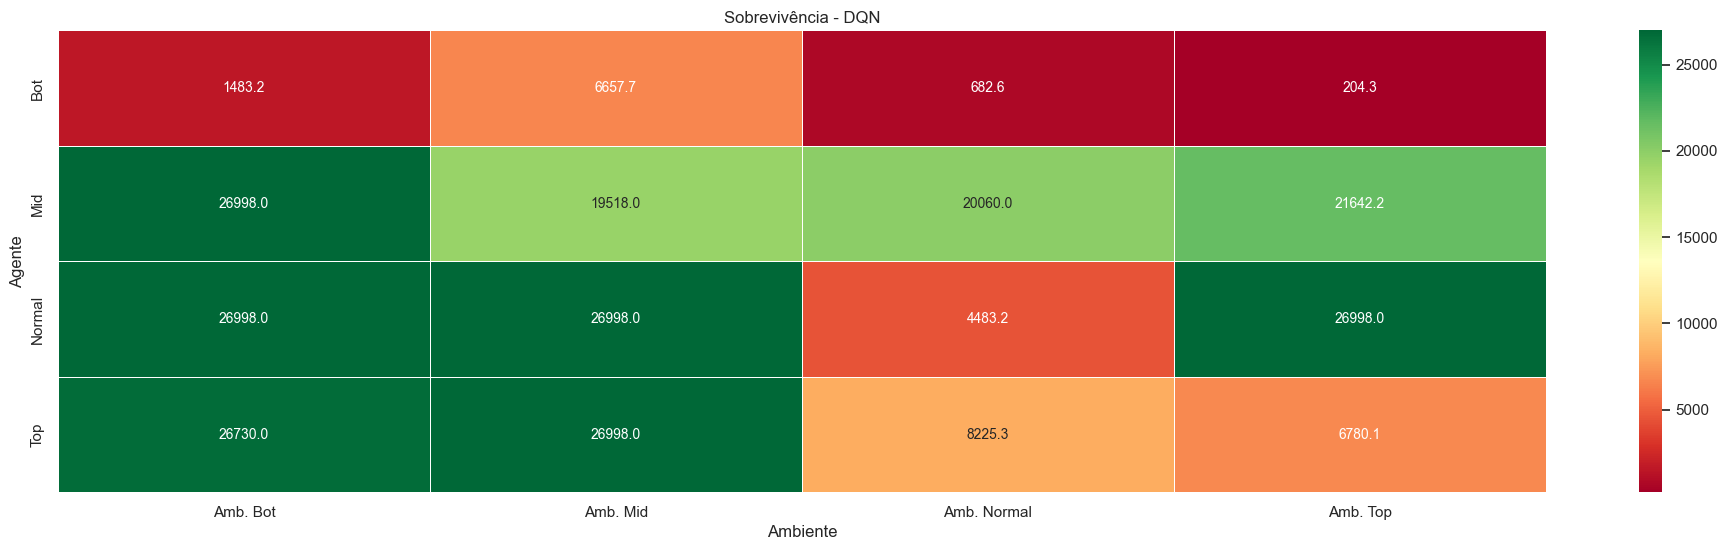

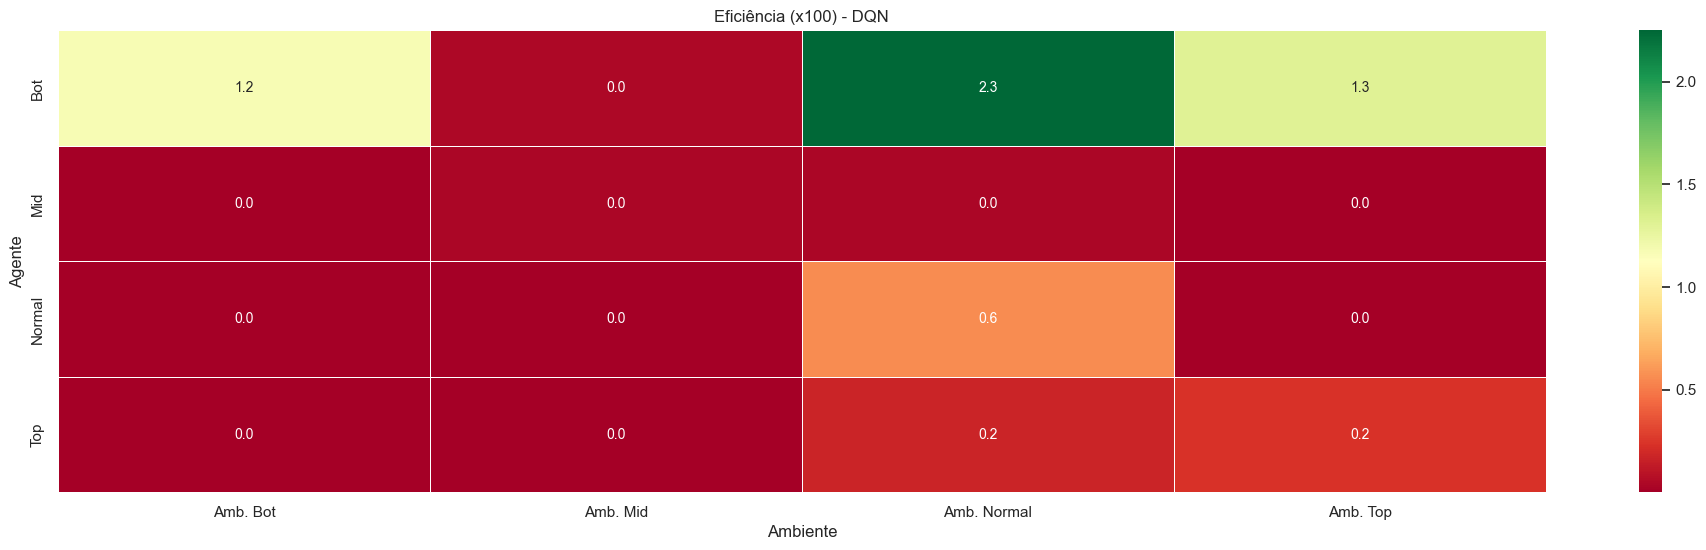

In [37]:
metrics = ["Score", "Sobrevivência", "Eficiência (x100)"]
    

for i, metric in enumerate(metrics):
    pivot = df.pivot(index="Agente", columns="Ambiente", values=metric)
    plt.subplots(figsize=(24, 6))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=.5)
    plt.title(f"{metric} - DQN")
    plt.show()
    

In [25]:
def compute_saliency(model, obs):
    """
    Calcula o mapa de saliência (atenção) via Gradiente.
    Versão robusta para DQN e PPO.
    """
    # 1. Prepara a observação para o PyTorch
    # Garante que está no formato (Batch, Channels, H, W) e no device correto (CPU/GPU)
    device = model.device
    obs_tensor = torch.from_numpy(obs).float().to(device)
    obs_tensor.requires_grad_() # Liga o rastreamento de gradiente

    # Coloca o modelo em modo de avaliação (desliga Dropout/BatchNorm se houver)
    model.policy.set_training_mode(False)

    # 2. Forward Pass (Calcula o Score)
    if isinstance(model, DQN):
        # --- DQN ---
        # Acessa diretamente a q_net. Ela já engloba a extração de features + MLP
        # O retorno são os Q-Values brutos para todas as ações
        q_values = model.q_net(obs_tensor)
        
        # Queremos explicar a ação que o agente ESCOLHEU (o maior Q-Value)
        target_action = torch.argmax(q_values)
        score = q_values[0, target_action]

    elif isinstance(model, PPO):
        # --- PPO ---
        # O PPO usa uma distribuição de probabilidade
        # distribution = model.policy.get_distribution(obs_tensor)
        
        # Precisamos passar pela rede de features primeiro, depois pela rede de ação (Actor)
        features = model.policy.extract_features(obs_tensor)
        latent_pi = model.policy.mlp_extractor.forward_actor(features)
        action_logits = model.policy.action_net(latent_pi)
        
        # Pega a ação mais provável e seu valor (logit)
        target_action = torch.argmax(action_logits)
        score = action_logits[0, target_action]

    else:
        raise ValueError("Modelo não suportado. Use DQN ou PPO.")

    # 3. Backward Pass (Calcula o Gradiente)
    # Zera gradientes anteriores para não acumular sujeira
    model.policy.zero_grad()
    
    # Calcula a derivada do Score em relação aos Pixels de entrada
    score.backward()

    # 4. Processa o Gradiente para virar uma Imagem
    # Saliency = Valor absoluto do gradiente nos pixels
    # Pegamos o gradiente do canal 3 (último frame empilhado, o 'agora')
    # obs_tensor.grad tem shape (1, 4, 84, 84)
    gradients = obs_tensor.grad.data.abs().cpu().numpy()
    saliency = gradients[0, 3, :, :] 

    # Normalização Robusta (para o mapa ficar bem visível)
    # Evita divisão por zero e estica o contraste
    val_min = saliency.min()
    val_max = saliency.max()
    if val_max > val_min:
        saliency = (saliency - val_min) / (val_max - val_min)
    
    return saliency

def visualize_attention(model, env, title="Attention Map"):
    # Reseta e avança um pouco para ter uma cena de jogo real
    obs = env.reset()
    for _ in range(30):
        # Usa o modelo para jogar um pouco
        action, _ = model.predict(obs, deterministic=True)
        # Se o jogo acabar no meio, reseta
        obs, _, done, _ = env.step(action)
        if isinstance(done, list): done = done[0] # Tratamento para VecEnv
        if done: obs = env.reset()

    # Calcula Saliência
    saliency_map = compute_saliency(model, obs)
    
    # Pega a imagem original (Frame 3 do Stack) para fundo
    # obs shape: (1, 4, 84, 84)
    original_img = obs[0, 3, :, :]

    # --- PLOTAGEM ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # 1. Visão do Agente (O que ele vê: Cinza 84x84)
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title("Visão do Agente (Grayscale)")
    axes[0].axis('off')
    
    # 2. Mapa de Atenção (Onde ele foca)
    # Plotamos a imagem original escura e o mapa de calor por cima
    axes[1].imshow(original_img, cmap='gray', alpha=0.5)
    
    # 'jet', 'hot' ou 'inferno' são bons colormaps para calor
    im = axes[1].imshow(saliency_map, cmap='inferno', alpha=0.8) 
    
    axes[1].set_title(f"Saliency Map (Foco de Atenção)\n{title}")
    axes[1].axis('off')
    
    # Adiciona barra de cor lateral
    cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Intensidade do Gradiente', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()

In [28]:
agente = 'normal' 
blur = False    
zone = 'middle'   

path = f"treino_dqn/dqn_breakout_{agente}"
if not os.path.exists(path) and os.path.exists(path + ".zip"):
    path += ".zip"
print(f"Carregando: {path}")
model = DQN.load(path)
env = make_training_env(with_blur=blur, zone=zone, log_dir=None)
visualize_attention(model, env, title=f"DQN {agente} no Ambiente")
env.close()

Carregando: treino_dqn/dqn_breakout_normal.zip


MemoryError: Unable to allocate 2.63 GiB for an array with shape (100000, 1, 4, 84, 84) and data type uint8

In [ ]:
# def record_video_run(algo_class, base_folder, agent_type, env_zone, blur=True):
#     prefix = "dqn" if algo_class == DQN else "ppo"
#     model_name = f"{prefix}_breakout_normal" if agent_type == "normal" else f"{prefix}_breakout_zone_{agent_type}"
#     model_path = os.path.join(base_folder, model_name)
    
#     video_name = f"Video_{prefix.upper()}_{agent_type}_on_{env_zone}"
#     folder = "./videos_finais/"
    
#     print(f"Gravando: {video_name}...")
    
#     # Cria ambiente com RecordVideo
#     def _env():
#         env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
#         env = FireResetEnv(env)
#         env = gym.wrappers.ResizeObservation(env, (84, 84))
        
#         # Presets (mesmos de cima)
#         presets = {'top': (32, 25, 20, 20), 'middle': (32, 50, 20, 20), 'bottom': (32, 64, 20, 20)}
#         region = presets.get(env_zone, (32, 50, 20, 20))
        
#         if blur: env = WhitePatchBreakout(env, apply_patch=True, region=region)
            
#         env = gym.wrappers.RecordVideo(env, video_folder=folder, name_prefix=video_name, disable_logger=True)
#         env = GrayscaleWrapper(env)
#         return env

#     env = DummyVecEnv([_env])
#     env = VecTransposeImage(env)
#     env = VecFrameStack(env, n_stack=4)
    
#     model = algo_class.load(model_path)
#     obs = env.reset()
    
#     # Grava 1 episódio completo
#     done = False
#     while not done:
#         action, _ = model.predict(obs, deterministic=True)
#         obs, _, done, _ = env.step(action)
#     env.close()
#     print("Salvo!")

In [ ]:
# record_video_run(DQN, "treino_dqn", agent_type="normal", env_zone="middle", blur=True)

Gravando: Video_DQN_normal_on_middle...
Salvo!


In [ ]:
# record_video_run(DQN, "treino_dqn", agent_type="normal", env_zone="top", blur=True)

Gravando: Video_DQN_normal_on_top...


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\user\Documents\mestrado\BlurRL\videos_finais folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Salvo!
